# TFLite로 경량화


In [5]:
load_path = r"C:\Users\User\Documents\GitHub\mlops\7_MLOps\cifar10_tuned_model\1"
best_model = keras.layers.TFSMLayer(load_path, call_endpoint='serving_default')


In [7]:
model_path = './cifar10_tuned_model/1'
model = keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

### SavedModel의 시그니처 확인

In [11]:
# SavedModel의 시그니처 확인 (Check SavedModel signatures)
print("\nModel signatures:", list(tf.saved_model.load(model_path).signatures.keys()))


Model signatures: ['serve', 'serving_default']


### SavedModel 모델 구조 확인

In [15]:
# SavedModel의 시그니처 확인 (Check SavedModel signatures)
saved_model = tf.saved_model.load(model_path)
infer = saved_model.signatures['serving_default']

print("\nModel Input Spec:")
for key, value in infer.structured_input_signature[1].items():
    print(f"Input {key}: shape = {value.shape}, dtype = {value.dtype}")

print("\nModel Output Spec:")
for key, value in infer.structured_outputs.items():
    print(f"Output {key}: shape = {value.shape}, dtype = {value.dtype}")


Model Input Spec:
Input keras_tensor_22: shape = (None, 32, 32, 3), dtype = <dtype: 'float32'>

Model Output Spec:
Output output_0: shape = (None, 10), dtype = <dtype: 'float32'>


### TF Lite 모델로 변환 & TF Lite 모델 저장

In [16]:
# TFLite 변환 (Convert to TFLite)
converter = tf.lite.TFLiteConverter.from_saved_model(model_path)
tflite_model = converter.convert()

# TFLite 모델 저장 (Save TFLite model)
with open('cifar10_model.tflite', 'wb') as f:
    f.write(tflite_model)

### TF Lite 모델 테스트


입력 텐서 정보 (Input tensor details):

이름 (Name): serving_default_keras_tensor_22:0
형태 (Shape): [ 1 32 32  3]
타입 (Type): <class 'numpy.float32'>

출력 텐서 정보 (Output tensor details):

이름 (Name): StatefulPartitionedCall_1:0
형태 (Shape): [ 1 10]
타입 (Type): <class 'numpy.float32'>


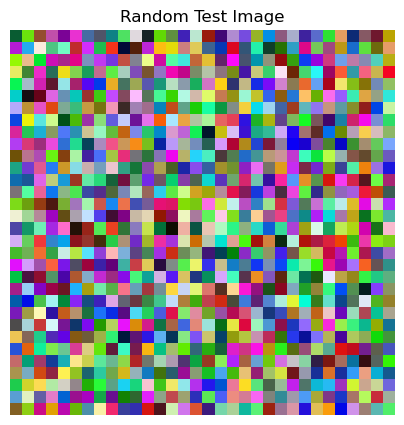


예측된 클래스 (Predicted class): automobile

각 클래스별 확률 (Probabilities for each class):
airplane: 0.0027
automobile: 0.8481
bird: 0.0001
cat: 0.0001
deer: 0.0216
dog: 0.0000
frog: 0.1140
horse: 0.0000
ship: 0.0000
truck: 0.0133


In [19]:
import numpy as np
import matplotlib.pyplot as plt


# TFLite 인터프리터 생성 (Create TFLite interpreter)
interpreter = tf.lite.Interpreter(model_path='cifar10_model.tflite')
interpreter.allocate_tensors()

# 입력과 출력 상세정보 가져오기 (Get input and output details)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n입력 텐서 정보 (Input tensor details):")
for detail in input_details:
    print(f"\n이름 (Name): {detail['name']}")
    print(f"형태 (Shape): {detail['shape']}")
    print(f"타입 (Type): {detail['dtype']}")

print("\n출력 텐서 정보 (Output tensor details):")
for detail in output_details:
    print(f"\n이름 (Name): {detail['name']}")
    print(f"형태 (Shape): {detail['shape']}")
    print(f"타입 (Type): {detail['dtype']}")

# 테스트 이미지 생성 (Create test image)
test_image = np.random.rand(1, 32, 32, 3).astype(np.float32)

# 이미지 시각화 (Visualize image)
plt.figure(figsize=(5, 5))
plt.imshow(test_image[0])  # [0]으로 배치 차원 제거 / Remove batch dimension with [0]
plt.title("Random Test Image")
plt.axis('off')
plt.show()

# 입력 텐서 설정 (Set input tensor)
interpreter.set_tensor(input_details[0]['index'], test_image)

# 추론 실행 (Run inference)
interpreter.invoke()

# 출력 가져오기 (Get output)
output_data = interpreter.get_tensor(output_details[0]['index'])

# CIFAR-10 클래스 이름 (CIFAR-10 class names)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 결과 출력 (Print results)
predicted_class = np.argmax(output_data[0])
print(f"\n예측된 클래스 (Predicted class): {class_names[predicted_class]}")
print("\n각 클래스별 확률 (Probabilities for each class):")
for i, (name, prob) in enumerate(zip(class_names, output_data[0])):
    print(f"{name}: {prob:.4f}")

### CIFAR-10 실제 이미지로 테스트

C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\3295499976.py:65: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from fon

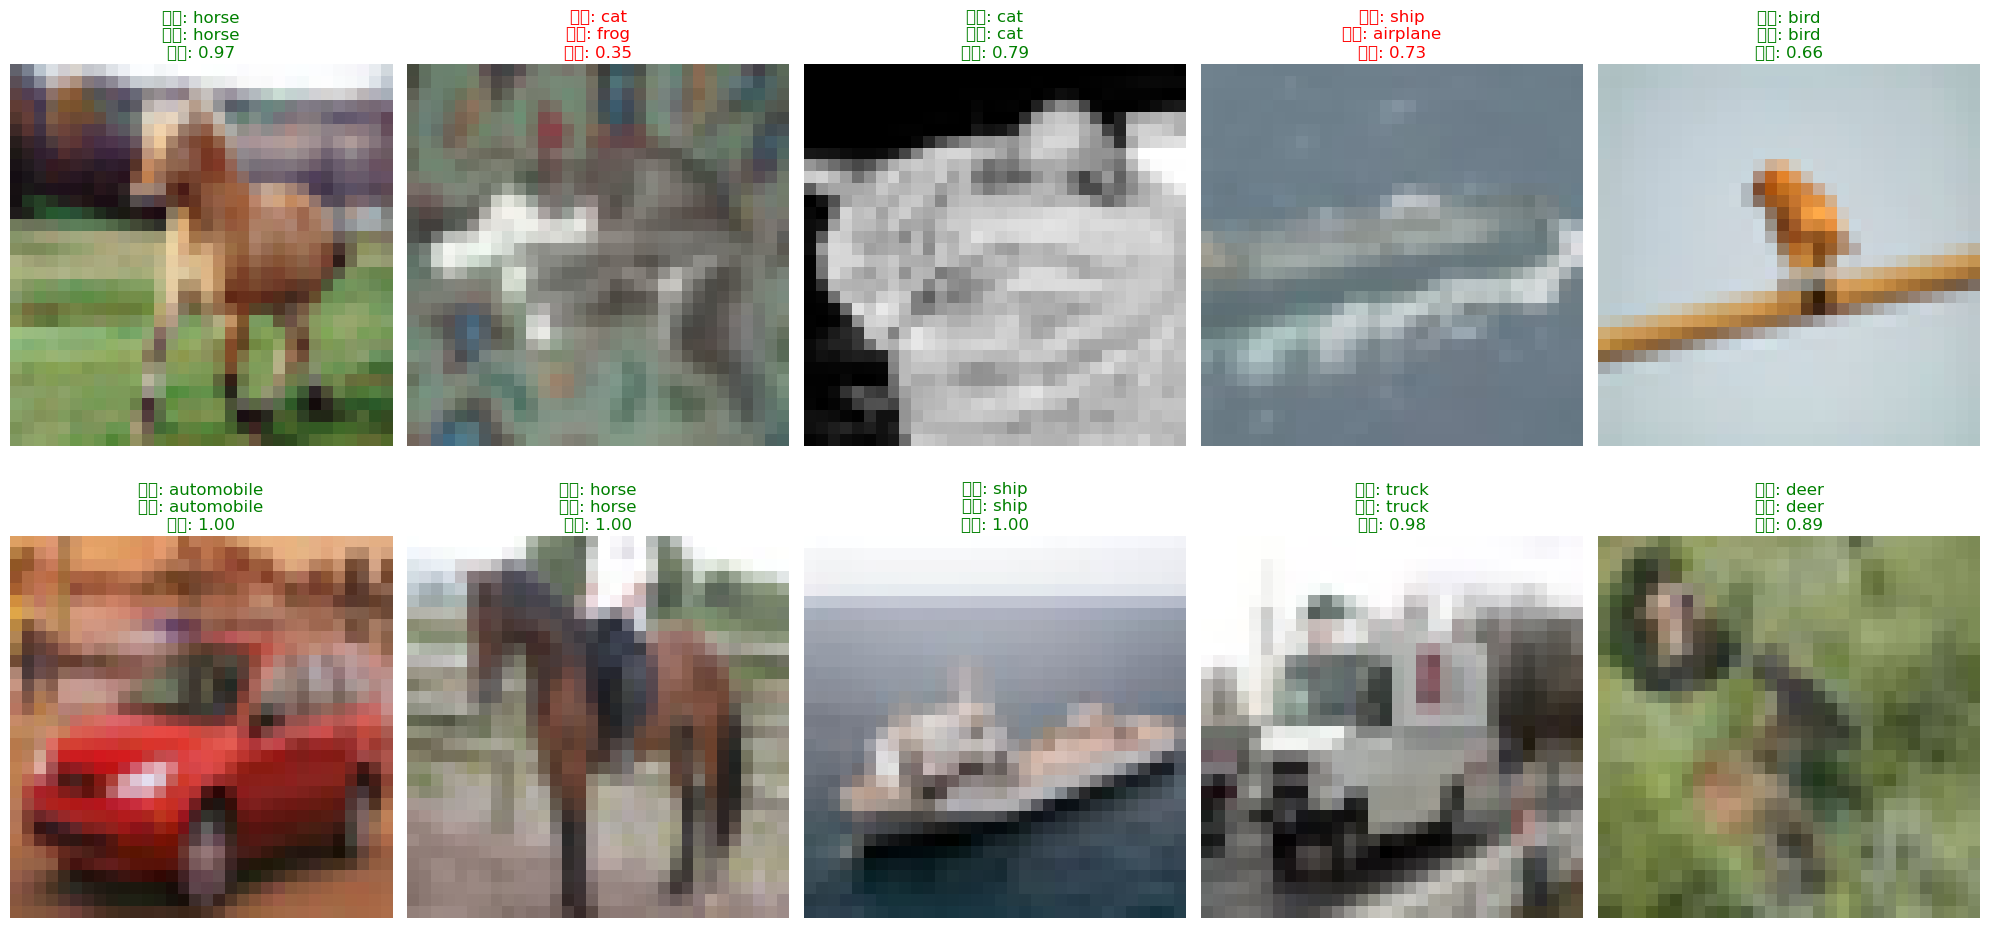


테스트 정확도 (Test Accuracy): 80.00%

예측 결과 상세 (Prediction Details):
실제 클래스 -> 예측 클래스
--------------------------------------------------
horse      -> horse      (정확)
cat        -> frog       (오류)
cat        -> cat        (정확)
ship       -> airplane   (오류)
bird       -> bird       (정확)
automobile -> automobile (정확)
horse      -> horse      (정확)
ship       -> ship       (정확)
truck      -> truck      (정확)
deer       -> deer       (정확)


In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 데이터 로드 (Load CIFAR-10 data)
(_, _), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# 테스트할 이미지 개수 (Number of images to test)
num_test = 10

# 랜덤하게 10개의 테스트 이미지 선택 (Randomly select 10 test images)
test_indices = np.random.choice(len(test_images), num_test, replace=False)
selected_images = test_images[test_indices]
selected_labels = test_labels[test_indices]

# 이미지 전처리 - 정규화 (Image preprocessing - normalization)
selected_images = selected_images.astype('float32') / 255.0

# TFLite 인터프리터 생성 (Create TFLite interpreter)
interpreter = tf.lite.Interpreter(model_path='cifar10_model.tflite')
interpreter.allocate_tensors()

# 입력과 출력 상세정보 가져오기 (Get input and output details)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# CIFAR-10 클래스 이름 (CIFAR-10 class names)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 결과를 저장할 리스트 (List to store results)
predictions = []
true_labels = []

# 결과를 시각화 (Visualize results)
plt.figure(figsize=(20, 10))

for i in range(num_test):
    # 이미지 준비 (Prepare image)
    test_image = selected_images[i:i+1]
    true_label = class_names[selected_labels[i][0]]
    true_labels.append(true_label)
    
    # 추론 실행 (Run inference)
    interpreter.set_tensor(input_details[0]['index'], test_image)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    
    # 예측 결과 얻기 (Get prediction result)
    predicted_class = class_names[np.argmax(output_data[0])]
    predictions.append(predicted_class)
    confidence = np.max(output_data[0])
    
    # 서브플롯 생성 (Create subplot)
    plt.subplot(2, 5, i + 1)
    plt.imshow(selected_images[i])
    
    # 제목 설정 - 초록색(맞춤) 또는 빨간색(틀림) (Set title - green(correct) or red(wrong))
    color = 'green' if true_label == predicted_class else 'red'
    
    plt.title(f'실제: {true_label}\n예측: {predicted_class}\n확률: {confidence:.2f}', 
              color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 정확도 계산 (Calculate accuracy)
correct = sum([1 for true, pred in zip(true_labels, predictions) if true == pred])
print(f"\n테스트 정확도 (Test Accuracy): {correct/num_test:.2%}")

# 혼동 행렬 출력 (Print confusion matrix)
print("\n예측 결과 상세 (Prediction Details):")
print("실제 클래스 -> 예측 클래스")
print("-" * 50)
for true, pred in zip(true_labels, predictions):
    print(f"{true:10} -> {pred:10} {'(정확)' if true == pred else '(오류)'}")

C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_31820\1972823818.py:73: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from fon

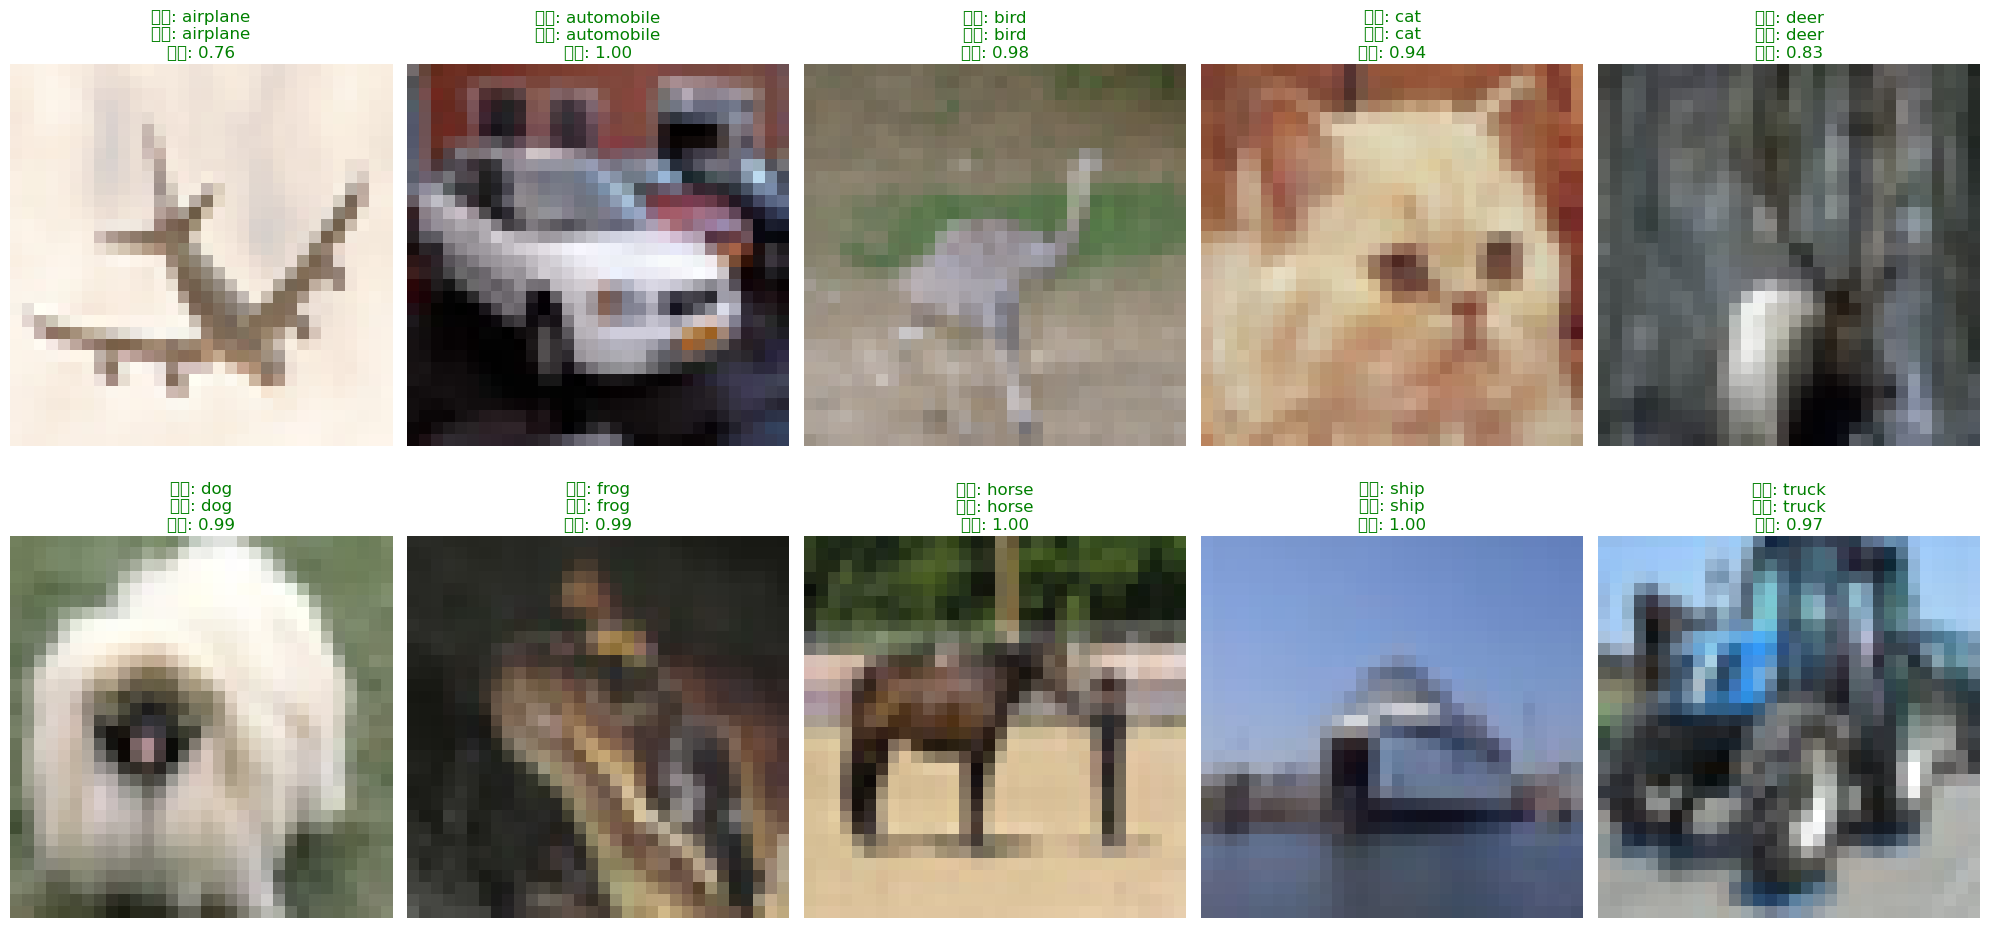


테스트 정확도 (Test Accuracy): 100.00%

예측 결과 상세 (Prediction Details):
실제 클래스 -> 예측 클래스
--------------------------------------------------
airplane   -> airplane   (정확)
automobile -> automobile (정확)
bird       -> bird       (정확)
cat        -> cat        (정확)
deer       -> deer       (정확)
dog        -> dog        (정확)
frog       -> frog       (정확)
horse      -> horse      (정확)
ship       -> ship       (정확)
truck      -> truck      (정확)


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 데이터 로드 (Load CIFAR-10 data)
(_, _), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 클래스 이름 (CIFAR-10 class names)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 각 클래스에서 1개씩 이미지 선택 (Select one image from each class)
selected_images = []
selected_labels = []

for class_idx in range(10):  # 10개 클래스에 대해
    # 현재 클래스의 이미지 인덱스들을 찾음 (Find indices of current class)
    class_indices = np.where(test_labels == class_idx)[0]
    # 해당 클래스에서 랜덤하게 1개 선택 (Randomly select one from the class)
    selected_idx = np.random.choice(class_indices, 1)[0]
    selected_images.append(test_images[selected_idx])
    selected_labels.append(test_labels[selected_idx])

# 리스트를 numpy 배열로 변환 (Convert lists to numpy arrays)
selected_images = np.array(selected_images)
selected_labels = np.array(selected_labels)

# 이미지 전처리 - 정규화 (Image preprocessing - normalization)
selected_images = selected_images.astype('float32') / 255.0

# TFLite 인터프리터 생성 (Create TFLite interpreter)
interpreter = tf.lite.Interpreter(model_path='cifar10_model.tflite')
interpreter.allocate_tensors()

# 입력과 출력 상세정보 가져오기 (Get input and output details)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 결과를 저장할 리스트 (List to store results)
predictions = []
true_labels = []

# 결과를 시각화 (Visualize results)
plt.figure(figsize=(20, 10))

for i in range(10):  # 10개 클래스
    # 이미지 준비 (Prepare image)
    test_image = selected_images[i:i+1]
    true_label = class_names[selected_labels[i][0]]
    true_labels.append(true_label)
    
    # 추론 실행 (Run inference)
    interpreter.set_tensor(input_details[0]['index'], test_image)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    
    # 예측 결과 얻기 (Get prediction result)
    predicted_class = class_names[np.argmax(output_data[0])]
    predictions.append(predicted_class)
    confidence = np.max(output_data[0])
    
    # 서브플롯 생성 (Create subplot)
    plt.subplot(2, 5, i + 1)
    plt.imshow(selected_images[i])
    
    # 제목 설정 - 초록색(맞춤) 또는 빨간색(틀림) (Set title - green(correct) or red(wrong))
    color = 'green' if true_label == predicted_class else 'red'
    
    plt.title(f'실제: {true_label}\n예측: {predicted_class}\n확률: {confidence:.2f}', 
              color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 정확도 계산 (Calculate accuracy)
correct = sum([1 for true, pred in zip(true_labels, predictions) if true == pred])
print(f"\n테스트 정확도 (Test Accuracy): {correct/10:.2%}")

# 혼동 행렬 출력 (Print confusion matrix)
print("\n예측 결과 상세 (Prediction Details):")
print("실제 클래스 -> 예측 클래스")
print("-" * 50)
for true, pred in zip(true_labels, predictions):
    print(f"{true:10} -> {pred:10} {'(정확)' if true == pred else '(오류)'}")